In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid, cumulative_trapezoid, solve_ivp
from scipy.optimize import fsolve
from scipy.interpolate import CubicSpline

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 4. Uso de curvas RTD para evaluar conversión en reactores reales

## 4.1

En un reactor real se puede considerar que cada elemento de fluido reacciona como un mini reactor batch idealizado, y tendrá una composición distinta de acuerdo con su tiempo de residencia en el reactor real.

Función analítica:

$$\left(\frac{\bar{C}_{\mathrm{A}}}{C_\mathrm{A}^{0}}\right) = \int_{0}^{\infty} \left(\frac{C_{\mathrm{A}}}{C_\mathrm{A}^{0}}\right) \cdot E(t) dt$$

Función numérica:

$$\left(\frac{\bar{C}_{\mathrm{A}}}{C_\mathrm{A}^{0}}\right) = \sum \left(\frac{C_{\mathrm{A}}}{C_\mathrm{A}^{0}}\right) \cdot E(t) \Delta t$$

## 4.2 Ejemplos

### 4.2.1 Ejemplo

    Levenspiel, Ex. 11.4

In [35]:
### Datos
t = np.array([0, 5, 10, 15, 20, 25, 30, 35]) # min
C = np.array([0, 3, 5, 5, 4, 2, 1, 0]) # g/dm3

### reactor model
C0 = 1
k = 0.307 # 1/min
r_A = lambda cA: -k*cA
def pfr(t, C):
    return np.array([-k*C[0]])

In [36]:
############## Calculo con RTD por integracion numerica
E = C / trapezoid(C, t) # E(t) discreta
### PFR: ODE solution (and conversion X)
t_span = (t[0], t[-1])
t_eval = t
sol1 = solve_ivp(pfr, t_span, y0=[C0], t_eval=t_eval)
X1 = 1 - sol1.y[0]/ C0
### CSTR: Algebraic
t1cstr = C0 * X1 / (-r_A(sol1.y[0]))
### segregated reactor conversion, Xseg
Xseg1 = cumulative_trapezoid(X1*E, t, initial=0)

In [37]:
############## Calculo con RTD por interpolacion e integracion
Es = CubicSpline(t, C/CubicSpline(t, C).integrate(t[0], t[-1]))   # E(t) spline
### PFR: ODE solution (and conversion X)
t_span = (t[0], t[-1])
t_eval = np.linspace(t_span[0], t_span[-1], 100)
sol2 = solve_ivp(pfr, t_span, y0=[C0], t_eval=t_eval)
X2 = 1 - sol2.y[0]/ C0
### CSTR: Algebraic
t2cstr = C0 * X2 / (-r_A(sol2.y[0]))
### segregated reactor conversion, Xseg
Xseg2 = np.array([CubicSpline(sol2.t, X2*Es(sol2.t)).integrate(0, t2) for t2 in sol2.t])

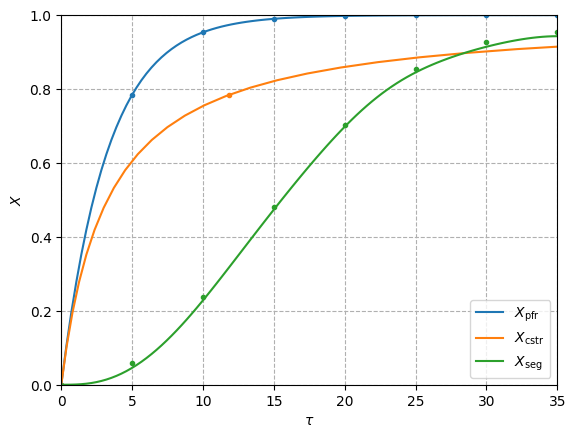

In [38]:
##### Graficos de resultados
fig, ax = plt.subplots()

# resultados basados en integracion numerica
ax.plot(sol1.t, X1, marker='.', ls='')
ax.plot(t1cstr, X1, marker='.', ls='')
ax.plot(sol1.t, Xseg1, marker='.', ls='')

ax.set_prop_cycle(None)
# resultados basados en interpolacion e integracion numerica
ax.plot(sol2.t, X2, label=r'$X_{\text{pfr}}$')
ax.plot(t2cstr, X2, label=r'$X_{\text{cstr}}$')
ax.plot(sol2.t, Xseg2, label=r"$X_{\text{seg}}$")

ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$X$")
ax.set_xlim(0, 35)
ax.set_ylim(0, 1)
ax.grid(ls='--')
ax.legend()
plt.show()

### 4.2.2 Ejemplo

    Fogler, Ex. 17.2

In [39]:
### Datos
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3

### reactor model
C0 = 1
k = 0.1 # 1/min
r_A = lambda cA: -k*cA
def pfr(t, C):
    return np.array([-k*C[0]])

In [40]:
############## Calculo con RTD por integracion numerica
E = C / trapezoid(C, t) # E(t) discreta
### PFR: ODE solution (and conversion X)
t_span = (t[0], t[-1])
t_eval = t
sol1 = solve_ivp(pfr, t_span, y0=[C0], t_eval=t_eval)
X1 = 1 - sol1.y[0]/ C0
### CSTR: Algebraic
t1cstr = C0 * X1 / (-r_A(sol1.y[0]))
### segregated reactor conversion, Xseg
Xseg1 = cumulative_trapezoid(X1*E, t, initial=0)

In [41]:
############## Calculo con RTD por interpolacion e integracion
Es = CubicSpline(t, C/CubicSpline(t, C).integrate(t[0], t[-1]))   # E(t) spline
### PFR: ODE solution (and conversion X)
t_span = (t[0], t[-1])
t_eval = np.linspace(t_span[0], t_span[-1], 100)
sol2 = solve_ivp(pfr, t_span, y0=[C0], t_eval=t_eval)
X2 = 1 - sol2.y[0]/ C0
### CSTR: Algebraic
t2cstr = C0 * X2 / (-r_A(sol2.y[0]))
### segregated reactor conversion, Xseg
Xseg2 = np.array([CubicSpline(sol2.t, X2*Es(sol2.t)).integrate(0, t2) for t2 in sol2.t])

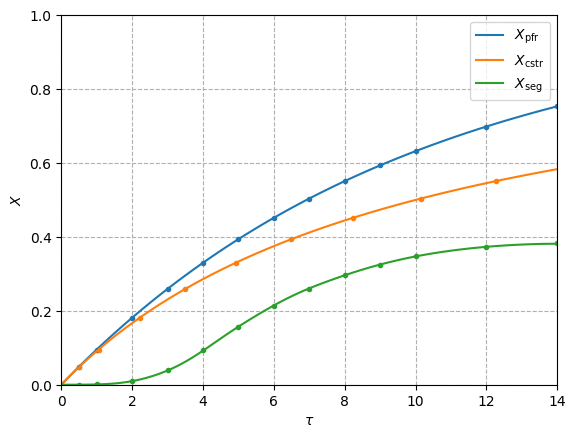

In [42]:
##### Graficos de resultados
fig, ax = plt.subplots()

# resultados basados en integracion numerica
ax.plot(sol1.t, X1, marker='.', ls='')
ax.plot(t1cstr, X1, marker='.', ls='')
ax.plot(sol1.t, Xseg1, marker='.', ls='')

ax.set_prop_cycle(None)
# resultados basados en interpolacion e integracion numerica
ax.plot(sol2.t, X2, label=r'$X_{\text{pfr}}$')
ax.plot(t2cstr, X2, label=r'$X_{\text{cstr}}$')
ax.plot(sol2.t, Xseg2, label=r"$X_{\text{seg}}$")

ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$X$")
ax.set_xlim(0, 14)
ax.set_ylim(0, 1)
ax.grid(ls='--')
ax.legend()
plt.show()